# Neuron ML Subsystem: Comprehensive Anomaly Detection
This notebook demonstrates the complete Machine Learning pipeline for the Neuron project. It is strictly divided into two distinct domains of Machine Learning applied to software:

*   **Part 1: Structural Anomaly Detection** (Using the NASA MDP Dataset - Tabular Data)
*   **Part 2: Semantic Defect Prediction** (Using NLP on CodeXGLUE-style Source Code Data)


---
# PART 1: Structural Anomaly Detection (NASA MDP Dataset)
We are using the NASA JM1 dataset which contains traditional software complexity metrics (Halstead, McCabe). Our goal is to detect defective modules based solely on their structural mathematics.


## Step 1: Exploratory Data Analysis (EDA)


Fetching NASA JM1 Dataset from OpenML...


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,1
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,1
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,1


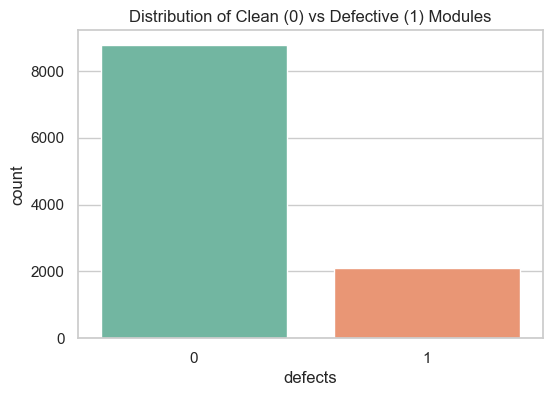

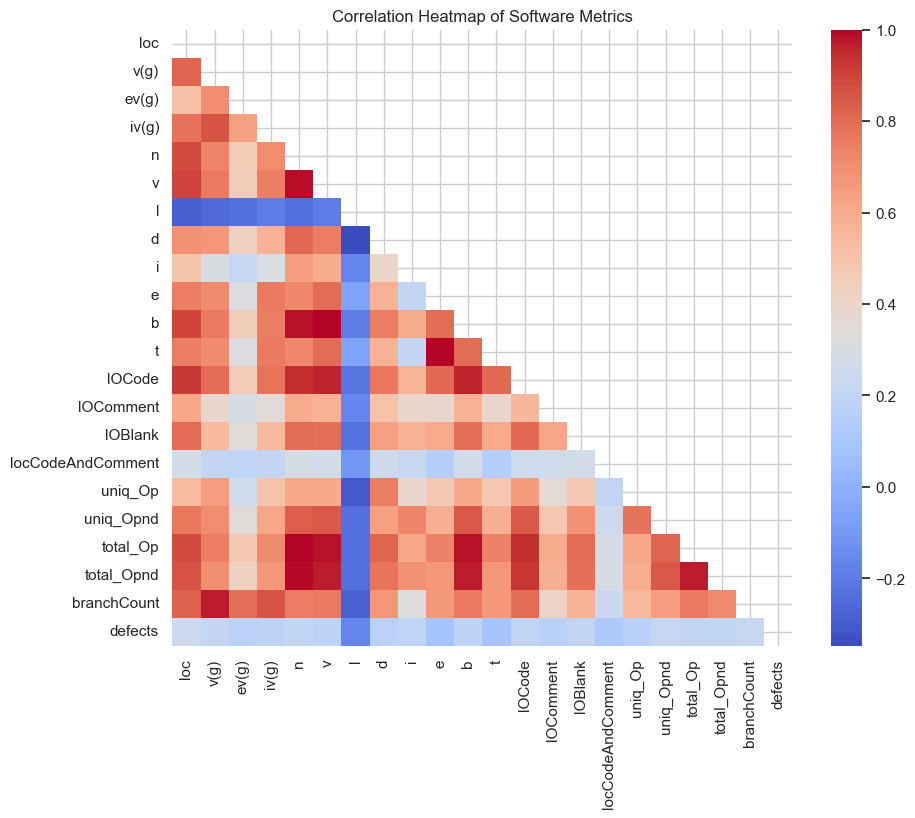

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Fetching NASA JM1 Dataset from OpenML...")
jm1 = fetch_openml(name='jm1', version=1, as_frame=True, parser='auto')
df = jm1.frame

# Clean target variable
df['defects'] = df['defects'].astype(str).map({'true': 1, 'false': 0, 'True': 1, 'False': 0})
df = df.dropna().reset_index(drop=True)

display(df.head())

# 1. Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='defects', palette='Set2')
plt.title('Distribution of Clean (0) vs Defective (1) Modules')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Software Metrics')
plt.show()


## Step 2: Unsupervised Learning (K-Means Clustering)
Before we use labels to predict defects, let's see if unsupervised learning can naturally group code modules into distinct architectural clusters (e.g., Simple vs. Spaghetti Code).


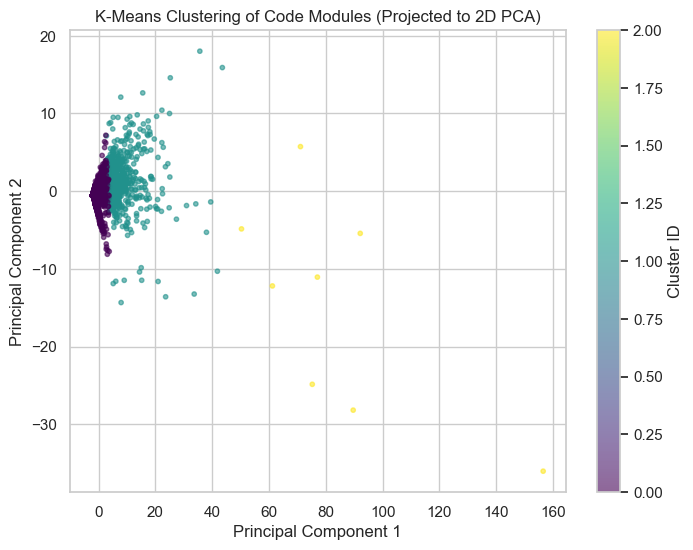

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_raw = df.drop('defects', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Use PCA to project down to 2 dimensions for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=10)
plt.title('K-Means Clustering of Code Modules (Projected to 2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()


## Step 3: Feature Derivation & Preprocessing (SMOTE & PCA)
To prepare for supervised learning, we must handle the extreme class imbalance using SMOTE and derive orthogonal features using PCA to remove multicollinearity.


In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

y = df['defects']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE for Imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# PCA for Dimensionality Reduction
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test)

print(f"Original Training Shape: {X_train.shape} | Defect Ratio: {np.mean(y_train):.2f}")
print(f"Resampled Training Shape: {X_train_res.shape} | Defect Ratio: {np.mean(y_train_res):.2f}")
print(f"Variance explained by 10 PCA components: {sum(pca.explained_variance_ratio_):.2f}")


Original Training Shape: (8704, 21) | Defect Ratio: 0.19
Resampled Training Shape: (14044, 21) | Defect Ratio: 0.50
Variance explained by 10 PCA components: 0.99


## Step 4: Classification & Regularization (L1 vs L2)
We train Logistic Regression models comparing L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting on noisy code metrics.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lr_l2 = LogisticRegression(penalty='l2', C=0.1, random_state=42)

lr_l1.fit(X_train_pca, y_train_res)
lr_l2.fit(X_train_pca, y_train_res)

print("Logistic Regression (L1 Regularization) Performance:")
print(classification_report(y_test, lr_l1.predict(X_test_pca)))


Logistic Regression (L1 Regularization) Performance:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1755
           1       0.35      0.61      0.44       421

    accuracy                           0.71      2176
   macro avg       0.62      0.67      0.62      2176
weighted avg       0.78      0.71      0.73      2176



## Step 5: Hyperparameter Tuning (GridSearchCV on SVM)
Finding the optimal hyperplane mathematically using Support Vector Machines.


In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Simplified grid for demonstration speed
param_grid = {'C': [0.1, 1], 'kernel': ['rbf']}
svm = SVC(probability=True, random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='recall', n_jobs=-1)

grid_search.fit(X_train_pca, y_train_res)
best_svm = grid_search.best_estimator_
print("Best SVM Parameters:", grid_search.best_params_)


Best SVM Parameters: {'C': 1, 'kernel': 'rbf'}


## Step 6: Ensemble Techniques (Random Forest & XGBoost)
State-of-the-art predictive modeling using decision tree ensembles to boost accuracy and reduce variance.


In [7]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_pca, y_train_res)

xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res) # Trained on scaled data (no PCA) for direct feature usage


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


## Step 7: Performance Analysis (ROC-AUC)
In defect prediction, **Recall** is king. We must catch bugs even if it means raising false alarms. We compare all models using ROC curves.


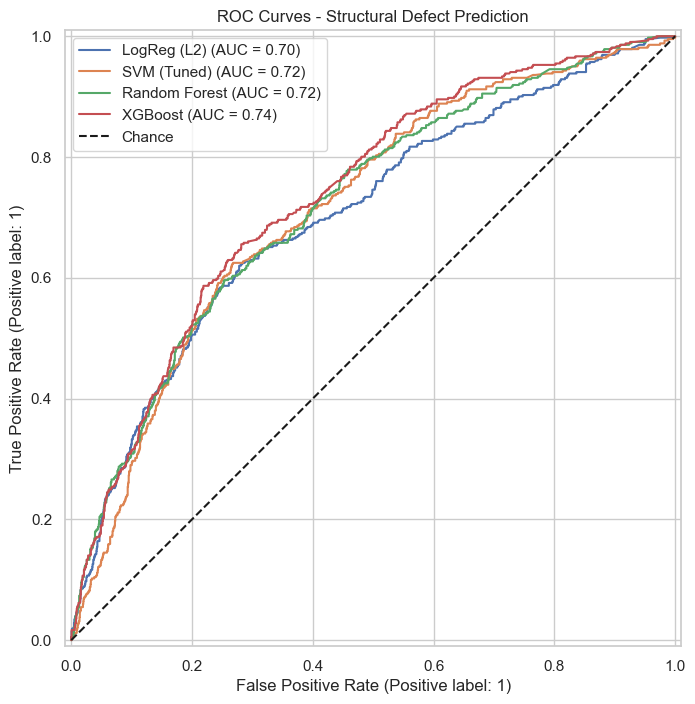

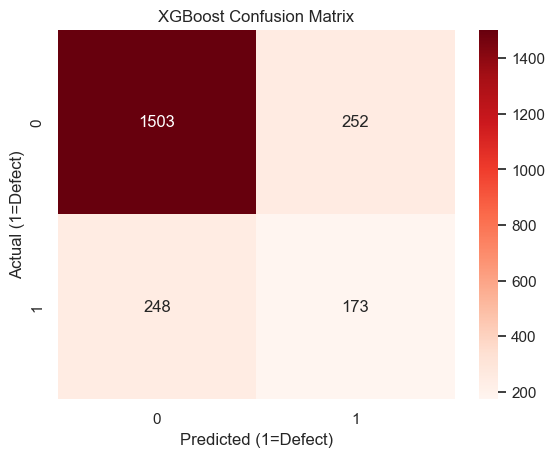

In [8]:
from sklearn.metrics import RocCurveDisplay, confusion_matrix

fig, ax = plt.subplots(figsize=(10, 8))
RocCurveDisplay.from_estimator(lr_l2, X_test_pca, y_test, name='LogReg (L2)', ax=ax)
RocCurveDisplay.from_estimator(best_svm, X_test_pca, y_test, name='SVM (Tuned)', ax=ax)
RocCurveDisplay.from_estimator(rf_model, X_test_pca, y_test, name='Random Forest', ax=ax)
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name='XGBoost', ax=ax)

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.title('ROC Curves - Structural Defect Prediction')
plt.legend()
plt.show()

# Final Confusion Matrix for XGBoost
sns.heatmap(confusion_matrix(y_test, xgb_model.predict(X_test)), annot=True, fmt='d', cmap='Reds')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted (1=Defect)')
plt.ylabel('Actual (1=Defect)')
plt.show()


---
# PART 2: Semantic Defect Prediction (NLP on Source Code)
Instead of structural metrics, modern ML (like the CodeXGLUE Benchmark) treats source code as a language. We use NLP (Natural Language Processing) to extract semantic features from the raw strings.


## Step 8: Code Feature Derivation (TF-IDF Vectorization)
We simulate a slice of CodeXGLUE with raw Python snippets, classified as Defective (1) or Clean (0).


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Simulated Raw Source Code Dataset
code_snippets = [
    "def login(user, pw): execute(f'SELECT * FROM users WHERE user={user}')", # SQL Injection (Defect)
    "def calc(a, b): return a / b", # Potential ZeroDivision (Defect)
    "def get_user(id): return db.query('SELECT * FROM users WHERE id=?', (id,))", # Safe (Clean)
    "def add(a, b): return a + b", # Safe (Clean)
    "eval(request.GET['data'])", # RCE Vulnerability (Defect)
    "def hello(): print('Hello World')" # Safe (Clean)
]
code_labels = [1, 1, 0, 0, 1, 0]

# Convert code strings to mathematical vectors using TF-IDF
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b|==|!=|<=|>=|\+|-|\*|/|=|\(|\)")
X_code_tfidf = vectorizer.fit_transform(code_snippets)

print("Vocabulary Extracted from Code:")
print(vectorizer.get_feature_names_out())

# Train a Naive Bayes Classifier on the Text Vectors
nb_model = MultinomialNB()
nb_model.fit(X_code_tfidf, code_labels)

# Test the Semantic Model
test_code = ["def run_query(q): db.execute(f'{q}')"]
test_vec = vectorizer.transform(test_code)
pred = nb_model.predict(test_vec)[0]

print(f"\nTest Code: {test_code[0]}\nPredicted Defect: {'YES (Anomaly Detected)' if pred == 1 else 'NO (Clean)'}")


Vocabulary Extracted from Code:
['(' ')' '*' '+' '/' '=' 'a' 'add' 'b' 'calc' 'data' 'db' 'def' 'eval'
 'execute' 'f' 'from' 'get' 'get_user' 'hello' 'id' 'login' 'print' 'pw'
 'query' 'request' 'return' 'select' 'user' 'users' 'where' 'world']

Test Code: def run_query(q): db.execute(f'{q}')
Predicted Defect: NO (Clean)
